# FAIRyMAGs (v0.4, 0.5) + MGnify + Magneto + nf-core, Ref

## Add output form this workflow: https://usegalaxy.eu/u/paulzierep/w/drep-fairymags-benchmark
## Example History: https://usegalaxy.eu/u/paulzierep/h/drep-fairymags-benchmark-1

In [1]:
#!/usr/bin/env python3

from bioblend.galaxy import GalaxyInstance
import pandas as pd
import io
import os
import sys
from pathlib import Path
from dotenv import load_dotenv

# === CONFIGURATION ===
load_dotenv(dotenv_path="../.env")

GALAXY_URL = "https://usegalaxy.eu"
API_KEY = os.getenv("GALAXY_API")

if not API_KEY:
    sys.exit("❌ GALAXY_API environment variable not set")

In [2]:
# Optional: output directory
OUTPUT_DIR = Path("input")
OUTPUT_DIR.mkdir(exist_ok=True)

# --- Connect to Galaxy ---
gi = GalaxyInstance(url=GALAXY_URL, key=API_KEY)


def download_dataset_as_df(dataset_id, name, sep=None, save=True):
    """
    Download a Galaxy dataset and return as pandas DataFrame.
    
    Parameters:
        dataset_id (str): Galaxy dataset ID
        name (str): Name for saving file
        sep (str): Separator (None = auto-detect CSV/TSV)
        save (bool): Save file locally
    
    Returns:
        pd.DataFrame
    """
    print(f"⬇️ Downloading dataset: {name} ({dataset_id})")

    content = gi.datasets.download_dataset(
        dataset_id,
        use_default_filename=False
    )

    buffer = io.BytesIO(content)

    # Try parsing
    if sep:
        df = pd.read_csv(buffer, sep=sep, comment="#")
    else:
        try:
            df = pd.read_csv(buffer, comment="#")
        except Exception:
            buffer.seek(0)
            df = pd.read_csv(buffer, sep="\t", comment="#")

    print(f"✅ Loaded {name} with shape {df.shape}")

    # Save locally
    if save:
        out_file = OUTPUT_DIR / f"{name}.tsv"
        df.to_csv(out_file, sep="\t", index=False)
        print(f"💾 Saved to {out_file}")

    return df


###################
# Load datasets
###################

cdb_95 = download_dataset_as_df(
    dataset_id="26c75dcccb616ac873ac172a13d2d53d",
    name="cdb_clusters_95"
)

checkm2 = download_dataset_as_df(
    dataset_id="26c75dcccb616ac8c86bad82e5971493",
    name="checkm2",
    sep="\t"
)

###################
# Preview
###################

print("\n--- CDB preview ---")
print(cdb_95.head())

print("\n--- CheckM2 preview ---")
print(checkm2.head())

⬇️ Downloading dataset: cdb_clusters_95 (26c75dcccb616ac873ac172a13d2d53d)
✅ Loaded cdb_clusters_95 with shape (2821, 6)
💾 Saved to input/cdb_clusters_95.tsv
⬇️ Downloading dataset: checkm2 (26c75dcccb616ac8c86bad82e5971493)
✅ Loaded checkm2 with shape (3141, 14)
💾 Saved to input/checkm2.tsv

--- CDB preview ---
                                              genome secondary_cluster  \
0       RNODE_577_length_7056_cov_38.11425_ref.fasta               1_0   
1       RNODE_578_length_7436_cov_10.94682_ref.fasta               2_0   
2                       1041930.PRJNA73221_ref.fasta               3_0   
3                      1120985.PRJNA188816_ref.fasta               4_0   
4  Leptodontidium_orchidicola_MPI-SW4-AT-0643.con...               5_0   

   threshold cluster_method comparison_algorithm  primary_cluster  
0       0.05        average                ANImf                1  
1       0.05        average                ANImf                2  
2       0.05        average          

In [3]:
MIN_COMPLETENESS = 75
MAX_CONTAMINATION = 25

hq_genomes = checkm2.loc[
    (checkm2["Completeness"] >= MIN_COMPLETENESS) &
    (checkm2["Contamination"] <= MAX_CONTAMINATION),
    "Name"
].unique()

print(f"✅ High-quality genomes: {len(hq_genomes)}")

✅ High-quality genomes: 1567


In [4]:
cdb_95["genome"] = cdb_95["genome"].str.replace(r"\.fasta$", "", regex=True)
cdb_95

,genome,secondary_cluster,threshold,cluster_method,comparison_algorithm,primary_cluster
0,RNODE_577_length_7056_cov_38.11425_ref,1_0,0.05,average,ANImf,1
1,RNODE_578_length_7436_cov_10.94682_ref,2_0,0.05,average,ANImf,2
2,1041930.PRJNA73221_ref,3_0,0.05,average,ANImf,3
3,1120985.PRJNA188816_ref,4_0,0.05,average,ANImf,4
4,Leptodontidium_orchidicola_MPI-SW4-AT-0643.con...,5_0,0.05,average,ANImf,5
...,...,...,...,...,...,...
2816,RNODE_597_length_13838_cov_20.78765_ref,845_0,0.05,average,ANImf,845
2817,RNODE_63_length_9116_cov_7.17902_ref,846_0,0.05,average,ANImf,846
2818,RNODE_80_length_5133_cov_7.08687_ref,847_0,0.05,average,ANImf,847
2819,RNODE_87_length_5673_cov_23.00212_ref,848_0,0.05,average,ANImf,848


In [5]:
cdb_filtered_95 = cdb_95[cdb_95["genome"].isin(hq_genomes)].copy()

print(f"✅ Filtered CDB shape: {cdb_filtered_95.shape}")
print(cdb_filtered_95.head())

✅ Filtered CDB shape: (1567, 6)
                     genome secondary_cluster  threshold cluster_method  \
2    1041930.PRJNA73221_ref               3_0       0.05        average   
3   1120985.PRJNA188816_ref               4_0       0.05        average   
9   1173027.PRJNA158839_ref              10_0       0.05        average   
57    320771.PRJNA20839_ref              42_0       0.05        average   
58    497964.PRJNA28531_ref              43_0       0.05        average   

   comparison_algorithm  primary_cluster  
2                 ANImf                3  
3                 ANImf                4  
9                 ANImf               10  
57                ANImf               42  
58                ANImf               43  


In [6]:
cdb_filtered_95['genome']

2        1041930.PRJNA73221_ref
3       1120985.PRJNA188816_ref
9       1173027.PRJNA158839_ref
57        320771.PRJNA20839_ref
58        497964.PRJNA28531_ref
                 ...           
2760      485918.PRJNA27951_ref
2761      523850.PRJNA20773_ref
2767    1353246.PRJNA210247_ref
2768    1365176.PRJNA212068_ref
2769      694427.PRJNA42009_ref
Name: genome, Length: 1567, dtype: str


Genomes per source:
source
True Genomes                   437
nf-core (v2)                   322
Metagenome tk (metaspades)     157
Metagenome tk (megahit) MSB    152
Metagenome tk (megahit)        131
nf-core (v1)                   123
MAGNETO (v2) MSB                88
MAGNETO (v1)                    56
MGnify                          36
FAIRyMAGs (v0.5)                35
FAIRyMAGs (v0.4)                30
Name: count, dtype: int64

Species-level representative MAGs:
source
FAIRyMAGs (v0.4)                30
FAIRyMAGs (v0.5)                35
MAGNETO (v1)                    10
MAGNETO (v2) MSB                13
MGnify                          36
Metagenome tk (megahit)         17
Metagenome tk (megahit) MSB     22
Metagenome tk (metaspades)      23
True Genomes                   386
nf-core (v1)                    26
nf-core (v2)                    28
dtype: int64


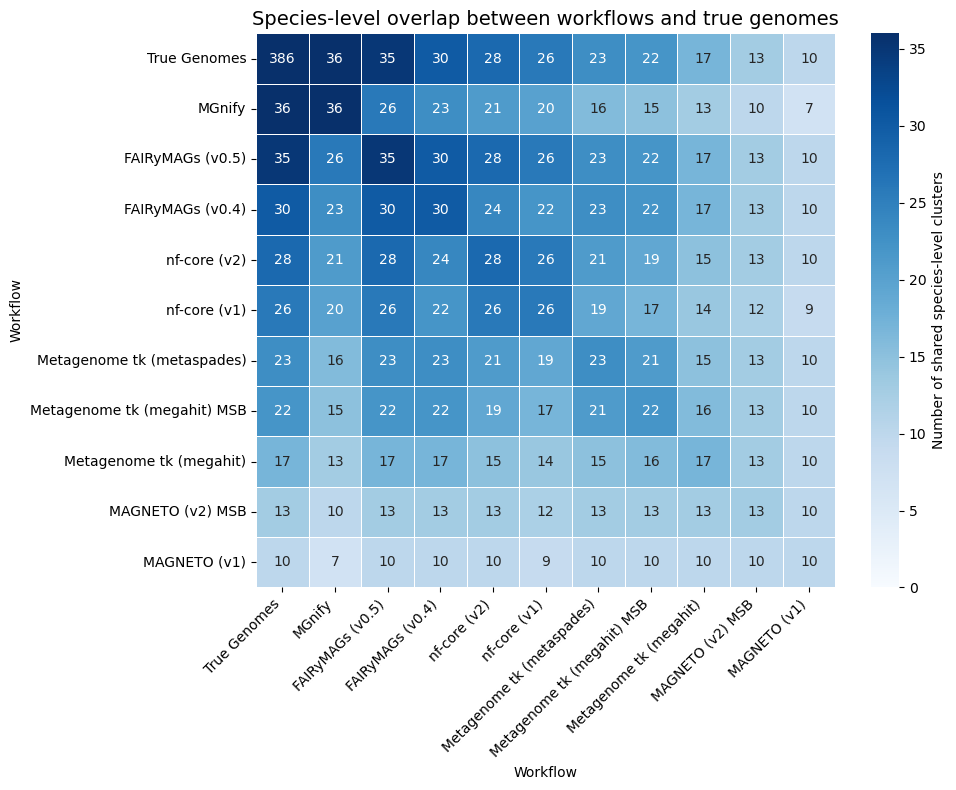

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Optional: output directory
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

# Assume df has 'genome' and 'secondary_cluster'
df = cdb_filtered_95.copy()

def get_source(name):
    if name.endswith('_ref'):
        return 'True Genomes'
    elif '_fairymags04' in name:
        return 'FAIRyMAGs (v0.4)'
    elif '_fairymags05' in name:
        return 'FAIRyMAGs (v0.5)'
    elif '_magneto_v1' in name:
        return 'MAGNETO (v1)'
    elif '_magneto_v2' in name:
        return 'MAGNETO (v2) MSB'
    elif '_nfcore_v1' in name:
        return 'nf-core (v1)'
    elif '_nfcore_v2' in name:
        return 'nf-core (v2)'
    elif '_mgnify' in name:
        return 'MGnify'
    elif '_metagenome_tk_metaspades' in name:
        return 'Metagenome tk (metaspades)'
    elif '_metagenome_tk_megahit_multisample' in name:
        return 'Metagenome tk (megahit) MSB'
    elif '_metagenome_tk_megahit' in name:
        return 'Metagenome tk (megahit)'
    else:
        return 'other'

# Assign workflow/source
df['source'] = df['genome'].apply(get_source)

# Print genome counts
print("\nGenomes per source:")
print(df['source'].value_counts())

# Count genomes per cluster per source
per_cluster = (
    df.groupby(['secondary_cluster', 'source'])
      .size()
      .unstack(fill_value=0)
)

# Convert to presence/absence
presence = per_cluster > 0

# Print dereplicated genome counts
print("\nSpecies-level representative MAGs:")
print(presence.sum())

# Create overlap matrix
sources = presence.columns
overlap_matrix = pd.DataFrame(0, index=sources, columns=sources)

# Count shared clusters
for i in sources:
    for j in sources:
        overlap_matrix.loc[i, j] = (
            (presence[i]) & (presence[j])
        ).sum()

# Sort by overlap with True Genomes
if 'True Genomes' in overlap_matrix.columns:
    sorted_sources = (
        overlap_matrix['True Genomes']
        .sort_values(ascending=False)
        .index
    )

    overlap_matrix = overlap_matrix.loc[
        sorted_sources,
        sorted_sources
    ]

# Optional: mask upper triangle
mask = np.triu(
    np.ones_like(overlap_matrix, dtype=bool),
    k=1
)

# Set heatmap color scale max excluding True Genomes
workflow_only = overlap_matrix.drop(
    index='True Genomes',
    columns='True Genomes',
    errors='ignore'
)

vmax = workflow_only.to_numpy().max()

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    overlap_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    vmin=0,
    vmax=vmax,
    # mask=mask,
    linewidths=0.5,
    cbar_kws={'label': 'Number of shared species-level clusters'}
)

plt.title(
    'Species-level overlap between workflows and true genomes',
    fontsize=14
)

plt.xlabel('Workflow')
plt.ylabel('Workflow')

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

# Save
plt.savefig(
    "plots/heatmap_mags_benchmark.svg",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "plots/heatmap_mags_benchmark.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()


/tmp/ipykernel_707873/3527553543.py:213: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


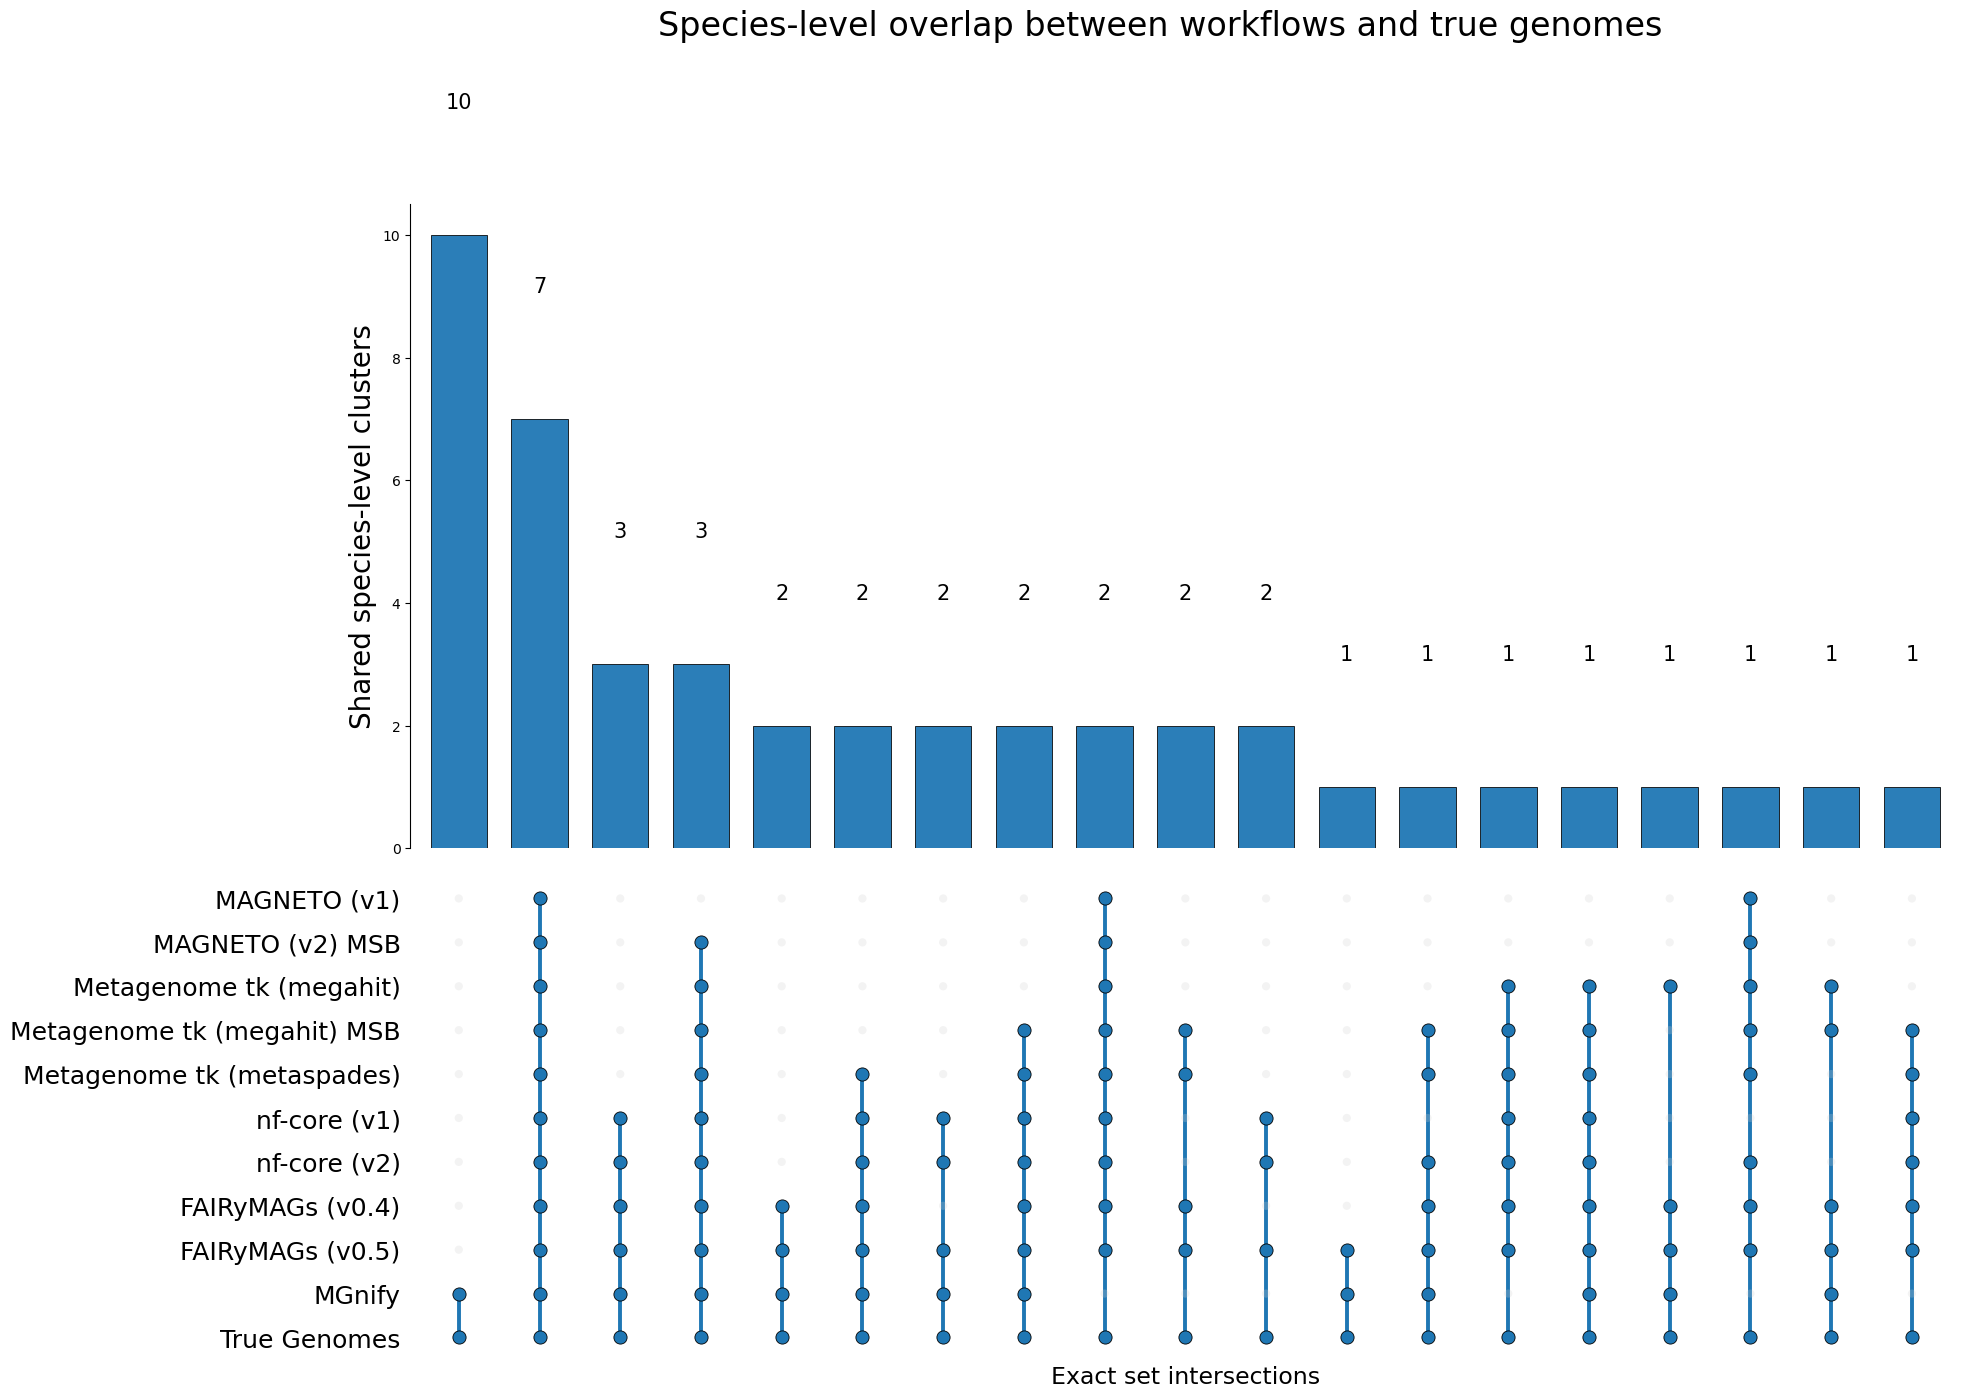

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

df['source'] = df['genome'].apply(get_source)
#df = df[df['source'] != 'MAGNETO (v2)']

per_cluster = (
    df.groupby(['secondary_cluster', 'source'])
      .size()
      .unstack(fill_value=0)
)

presence = per_cluster > 0
sources = list(presence.columns)

# ------------------------
# Sort by overlap with True Genomes
# ------------------------

if 'True Genomes' in sources:

    overlap_with_ref = {
        s: (presence[s] & presence['True Genomes']).sum()
        for s in sources
    }

    sources = sorted(
        sources,
        key=lambda s: overlap_with_ref[s],
        reverse=True
    )

    presence = presence[sources]

# ------------------------
# TRUE UpSet signatures
# ------------------------

signatures = presence.astype(int).apply(tuple, axis=1)
signature_counts = signatures.value_counts()

# ------------------------
# KEEP ALL intersections
# BUT REMOVE:
# True Genomes-only singleton
# ------------------------

intersections = []

for sig, count in signature_counts.items():

    if count == 0:
        continue

    # Remove only:
    # (True Genomes = 1) AND all others = 0
    if 'True Genomes' in sources:

        ref_idx = sources.index('True Genomes')

        if (
            sig[ref_idx] == 1
            and sum(sig) == 1
        ):
            continue

    intersections.append({
        'sets': sig,
        'size': count
    })

# Sort descending
intersections.sort(key=lambda x: -x['size'])

# ------------------------
# SHOW ALL intersections
# ------------------------

top = intersections

# ------------------------
# Plot
# ------------------------

fig = plt.figure(figsize=(20, 15))

gs = GridSpec(
    2,
    1,
    figure=fig,
    height_ratios=[2, 1.5],
    hspace=0.05
)

ax_bar = fig.add_subplot(gs[0])
ax_dot = fig.add_subplot(gs[1])

n_cols = len(top)

COLOR = '#1f77b4'

# ------------------------
# BAR PLOT
# ------------------------

for i, inter in enumerate(top):

    ax_bar.bar(
        i,
        inter['size'],
        color=COLOR,
        alpha=0.95,
        width=0.7,
        edgecolor='black',
        linewidth=0.6
    )

    ax_bar.text(
        i,
        inter['size'] + 2,
        str(inter['size']),
        ha='center',
        va='bottom',
        fontsize=15
    )

ax_bar.set_xlim(-0.6, n_cols - 0.4)

ax_bar.set_xticks([])

ax_bar.set_ylabel(
    'Shared species-level clusters',
    fontsize=20
)

ax_bar.spines[['top', 'right', 'bottom']].set_visible(False)

# ------------------------
# DOT MATRIX
# ------------------------

ax_dot.set_xlim(-0.6, n_cols - 0.4)

ax_dot.set_ylim(
    -0.5,
    len(sources) - 0.5
)

ax_dot.set_xticks([])

ax_dot.set_yticks(range(len(sources)))

ax_dot.set_yticklabels(
    sources,
    fontsize=18
)

ax_dot.spines[
    ['top', 'right', 'bottom', 'left']
].set_visible(False)

ax_dot.tick_params(left=False)

for i, inter in enumerate(top):

    sig = inter['sets']

    active_rows = [
        idx for idx, v in enumerate(sig)
        if v == 1
    ]

    # Connection line
    if len(active_rows) > 1:

        ax_dot.plot(
            [i, i],
            [min(active_rows), max(active_rows)],
            color=COLOR,
            lw=2.8,
            zorder=1
        )

    # Dots
    for ri in range(len(sources)):

        active = sig[ri] == 1

        ax_dot.scatter(
            i,
            ri,
            s=90 if active else 35,
            color=COLOR if active else '#d0d0d0',
            alpha=1.0 if active else 0.25,
            edgecolor='black' if active else 'none',
            linewidth=0.6,
            zorder=2
        )

ax_dot.set_xlabel(
    'Exact set intersections',
    fontsize=17
)

plt.suptitle(
    'Species-level overlap between workflows and true genomes',
    fontsize=24,
    y=1.01
)

plt.tight_layout()

plt.savefig(
    'plots-v3/upset_mags_benchmark.svg',
    dpi=300,
    bbox_inches='tight'
)

plt.savefig(
    'plots-v3/upset_mags_benchmark.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

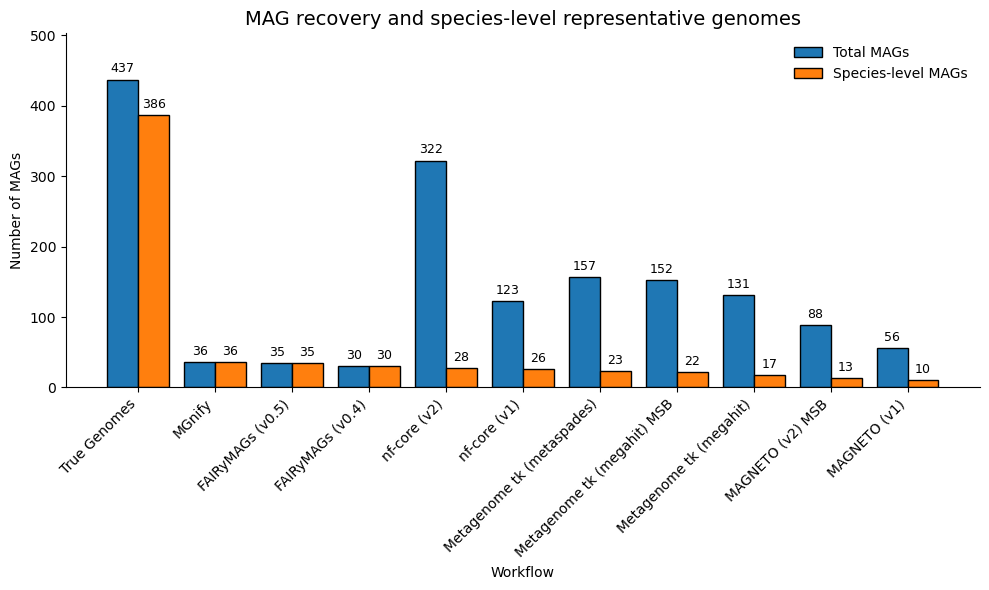

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Prepare data ---
counts = df['source'].value_counts()
cluster_counts = presence.sum()

# Sort by species-level MAG recovery
order = cluster_counts.sort_values(ascending=False).index

# Reorder both series
counts = counts.reindex(order)
cluster_counts = cluster_counts.reindex(order)

# --- Set positions ---
x = np.arange(len(order))
width = 0.4

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(
    x - width/2,
    counts,
    width,
    label="Total MAGs",
    edgecolor='black'
)

bars2 = ax.bar(
    x + width/2,
    cluster_counts,
    width,
    label="Species-level MAGs",
    edgecolor='black'
)

# --- Add value labels ---
ax.bar_label(bars1, padding=3, fontsize=9)
ax.bar_label(bars2, padding=3, fontsize=9)

# --- Prevent clipping ---
max_val = max(counts.max(), cluster_counts.max())
ax.set_ylim(0, max_val * 1.15)

# --- Labels & styling ---
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=45, ha='right')

ax.set_ylabel("Number of MAGs")
ax.set_xlabel("Workflow")

ax.set_title(
    "MAG recovery and species-level representative genomes",
    fontsize=14
)

ax.legend(frameon=False)

# Cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# --- Save ---
plt.savefig(
    "plots-v3/mags_grouped_bar_with_values.svg",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "plots-v3/mags_grouped_bar_with_values.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

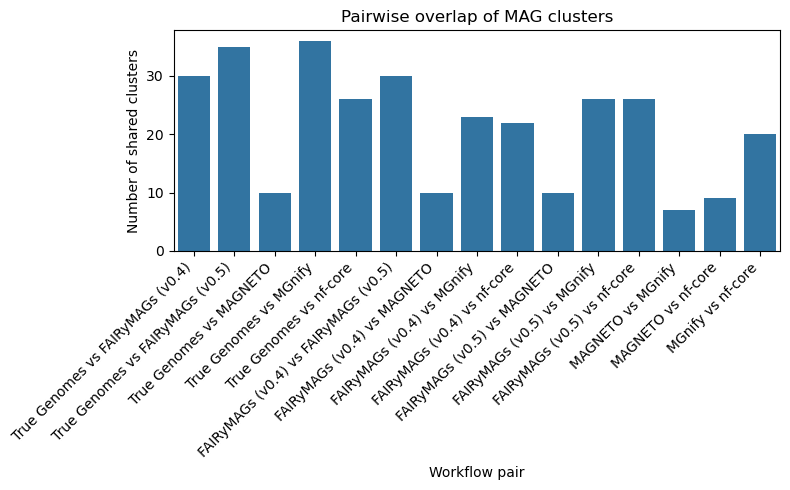

In [9]:
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import seaborn as sns

pairs = []

sources = overlap_matrix.columns

for i, j in itertools.combinations(sources, 2):
    pairs.append({
        "pair": f"{i} vs {j}",
        "overlap": overlap_matrix.loc[i, j]
    })

pairs_df = pd.DataFrame(pairs)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=pairs_df, x="pair", y="overlap")

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of shared clusters")
plt.xlabel("Workflow pair")
plt.title("Pairwise overlap of MAG clusters")
plt.tight_layout()
plt.show()

In [ ]:
# Identify clusters that contain at least one true genome
ref_clusters = presence[presence['True Genomes']].index

results = []

for source in ['FAIRyMAGs', 'MAGNETO', 'MGnify']:
    
    # Clusters where this workflow has MAGs
    pred_clusters = presence[presence[source]].index
    
    # True Positives: predicted clusters that match reference clusters
    tp = len(set(pred_clusters) & set(ref_clusters))
    
    # False Positives: predicted clusters without reference
    fp = len(set(pred_clusters) - set(ref_clusters))
    
    # False Negatives: reference clusters not recovered
    fn = len(set(ref_clusters) - set(pred_clusters))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    results.append({
        "source": source,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "precision": precision,
        "recall": recall
    })

metrics_df = pd.DataFrame(results)

print("\n=== Precision / Recall per workflow ===")
print(metrics_df)


=== Precision / Recall per workflow ===
      source  TP  FP   FN  precision    recall
0  FAIRyMAGs  30   0  355        1.0  0.077922
1    MAGNETO  10   0  375        1.0  0.025974
2     MGnify  36   0  349        1.0  0.093506


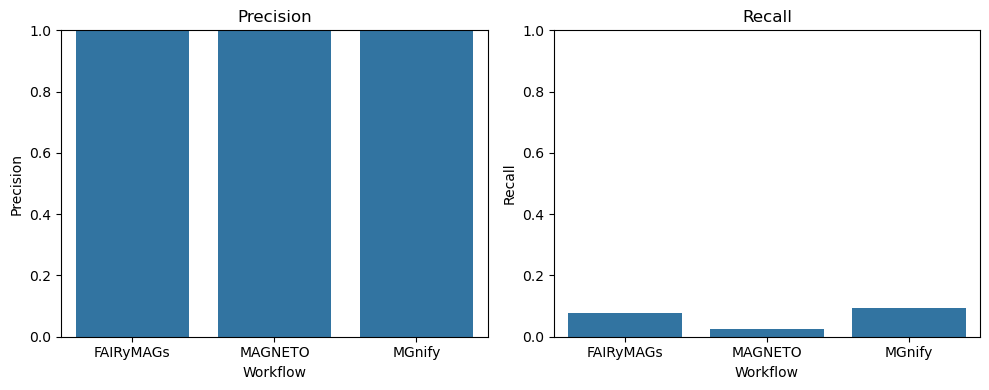

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Precision plot ---
sns.barplot(
    data=metrics_df,
    x="source",
    y="precision",
    ax=axes[0]
)
axes[0].set_title("Precision")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Precision")
axes[0].set_xlabel("Workflow")

# --- Recall plot ---
sns.barplot(
    data=metrics_df,
    x="source",
    y="recall",
    ax=axes[1]
)
axes[1].set_title("Recall")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Recall")
axes[1].set_xlabel("Workflow")

plt.tight_layout()
plt.show()

# Version 2 (+nf-core mags and fairymags 0.5)